# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [66]:
# importar librerías
import pandas as pd

In [67]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [68]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [69]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [70]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [71]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [72]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [73]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [74]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [75]:
# cantidad de valores nulos para users (por columnas)

print(users.isnull().sum()) # Cantidad de valores nulos por columna

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [76]:

# cantidad de valores nulos para users (total)

print(users.isnull().sum().sum())


4003


In [77]:

# proporción de valores nulos para users (por columnas)

print(users.isnull().mean()*100)




user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [78]:
# cantidad de valores nulos para usage (por columnas)

print(usage.isnull().sum()) # Cantidad de valores nulos por columna

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


In [79]:
# cantidad de valores nulos para usage (total)

print(usage.isnull().sum().sum())


40022


In [80]:
# proporción de valores nulos para usage (por columnas)

print(usage.isnull().mean()*100)


id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


In [81]:
plans.duplicated().sum()

0

In [82]:
users.duplicated().sum()

0

In [83]:
usage.duplicated().sum()

0

No se observan registros que se encuentren duplicados en ninguno de los conjuntos de datos que fueron proporcionados.

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?


En el caso de los datos contenidos en el conjunto de datos users, se identificaron las siguientes características relacionadas con la presencia de valores faltantes:

- Se detectó un total de 4003 valores nulos dentro del conjunto de datos.

- La distribución de estos valores nulos corresponde a 469 registros en la columna city y 3534 registros en la columna churn_date.

- La proporción de valores nulos respecto al total de registros de cada columna es de 11.725 % para city y 88.35 % para churn_date.

- Para la columna city, dado que los valores faltantes representan únicamente el 11.725 % de los registros y no se dispone de información complementaria que permita realizar una imputación confiable, se recomienda conservar dichos valores como nulos.

- En el caso de la columna churn_date, debido a la elevada proporción de valores faltantes (88.35 %), se considera que esta variable aporta información limitada para el análisis. Por ello, se recomienda excluirla del proceso analítico o interpretar sus resultados con cautela, según los objetivos específicos del estudio.



En el conjunto de datos usage se identificaron las siguientes características relacionadas con la presencia de valores faltantes:

- Se detectó un total de 40 022 valores nulos dentro del conjunto de datos.

- La distribución de estos valores nulos corresponde a 50 registros en la columna date, 22 076 registros en la columna duration y 17 896 registros en la columna length.

- La proporción de valores nulos respecto al total de registros de cada columna es de 0.125 % para date, 55.19 % para duration y 44.74 % para length.

- Con relación a la columna date, la proporción de valores faltantes es reducida (0.125 % del total de registros), por lo que resulta viable aplicar un procedimiento de imputación sin afectar significativamente la calidad de los datos. Dicha imputación puede realizarse considerando el identificador (id) de cada registro y las fechas asociadas a identificadores cercanos al registro con información faltante, preservando así la coherencia temporal y la estructura secuencial del conjunto de datos.

- En cuanto a las columnas duration y length, los valores nulos observados parecen responder a la naturaleza de la información registrada y no necesariamente a errores o pérdidas de datos. Del análisis de la muestra se observa que, cuando el registro corresponde a una llamada, la variable length carece de relevancia y permanece vacía; de forma análoga, cuando el registro corresponde a un mensaje, la variable duration no resulta aplicable y, por tanto, se mantiene sin valor. En consecuencia, estos valores nulos pueden considerarse estructurales y no requieren procesos de imputación o tratamiento adicional.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [84]:

# explorar columnas numéricas de users
for columna in users.columns:
    print(f"\nResumen de {columna}")
    print(users[columna].describe())




Resumen de user_id
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

Resumen de first_name
count      4000
unique        6
top       Mateo
freq        685
Name: first_name, dtype: object

Resumen de last_name
count      4000
unique        5
top       Lopez
freq        835
Name: last_name, dtype: object

Resumen de age
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

Resumen de city
count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

Resumen de reg_date
count                              4000
unique                             3961
top       2026-05-10 00:00:00.000000000
freq                                 40
Name: reg_date, dtype: object

Resum

In [85]:
# Cantidad de valores no válidos (equivalentes al mínimo)
(users['age'] == -999).sum()

55

In [86]:

# Cantidad de valores no válidos
(users['age'] < 0).sum()


55

In [87]:
# Cantidad de valores no válidos
users['age'].median()

47.0


- La columna user_id contiene un total de 4000 registros.

- La columna age presenta una edad promedio de 33.74 años. Sin embargo, la desviación estándar es de 123.23 años, lo que indica una elevada dispersión de los datos. Este comportamiento se debe principalmente a la presencia de valores atípicos o no válidos dentro de la columna.

- El valor mínimo registrado es -999, el cual no corresponde a una edad válida. Asimismo, se observa que este es el único valor negativo presente en la columna. Por otro lado, el valor máximo registrado es 79 años, considerado consistente dentro del contexto de la variable analizada.

- La presencia del valor -999 sugiere que este pudo haber sido utilizado como un marcador para representar datos faltantes o desconocidos. En consecuencia, se recomienda reemplazar dicho valor por un valor nulo (NaN) y posteriormente aplicar una estrategia de imputación.

- Dado que la mediana es una medida robusta frente a valores atípicos, se recomienda utilizarla para imputar los registros faltantes una vez que el valor -999 haya sido tratado como dato ausente. Para ello, es necesario recalcular la mediana excluyendo previamente los valores no válidos.

In [88]:
# explorar columnas numéricas de usage
for columna in usage.columns:
    print(f"\nResumen de {columna}")
    print(usage[columna].describe())



Resumen de id
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

Resumen de user_id
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

Resumen de type
count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Resumen de date
count                             39950
unique                            39950
top       2024-01-03 09:27:03.010575264
freq                                  1
Name: date, dtype: object

Resumen de duration
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64

Resumen de length
count    


- Las columnas id y user_id no presentan valores faltantes ni registros inválidos, por lo que se consideran completas y consistentes para su utilización en el análisis.

- La columna type contiene dos categorías de registros. El análisis de su distribución evidencia una mayor frecuencia de registros correspondientes a mensajes en comparación con las llamadas, lo que indica una predominancia de este tipo de interacción dentro del conjunto de datos.

- Se registró un total de 1 792 llamadas, con una duración media de 5.20 minutos y una desviación estándar de 6.84 minutos, lo que refleja una variabilidad considerable en la duración de las comunicaciones. La duración mínima observada es de 0 minutos, mientras que la máxima alcanza los 120 minutos. Este valor máximo podría considerarse un valor atípico debido a su alejamiento respecto a la media de la distribución. Por otro lado, las llamadas con duración nula podrían corresponder a intentos de comunicación no concretados o finalizados antes de establecerse la conexión.

- Se registró un total de 22 104 mensajes. La longitud de los mensajes presenta un valor medio de 52.13 caracteres y una desviación estándar de 56.61 caracteres, lo que indica una alta dispersión en el tamaño de los mensajes intercambiados. La longitud mínima observada es de 0 caracteres, mientras que la máxima alcanza los 1 490 caracteres. Los valores de longitud más elevados pueden corresponder a casos atípicos o a mensajes excepcionalmente extensos. En contraste, los registros con longitud nula podrían indicar errores en la captura de la información, registros incompletos o mensajes vacíos, por lo que resulta conveniente analizar estos casos con mayor detalle antes de su inclusión en etapas posteriores del análisis.

In [89]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for i in columnas_user:
    print(users[i].unique())


['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']


- La columna city contiene un total de ocho categorías distintas, de las cuales seis corresponden a valores válidos. Las dos categorías restantes se asocian a registros inválidos: valores faltantes (NaN) y la etiqueta "?". Debido a la ausencia de información adicional que permita inferir correctamente la ciudad correspondiente, no es posible aplicar un procedimiento de corrección o imputación confiable para estos casos. Asimismo, no se identificaron inconsistencias en la nomenclatura de las categorías válidas que sugieran la existencia de registros duplicados por diferencias de escritura. Las ciudades registradas en el conjunto de datos son Medellín, CDMX (Ciudad de México), Bogotá, GDL (Guadalajara), MTY (Monterrey) y Cali.
- La columna plan contiene dos categorías: Básico y Premium. No se identificaron valores inválidos, categorías ambiguas ni inconsistencias en el etiquetado, por lo que la variable se considera consistente y apta para su utilización en el análisis.

In [90]:
# explorar columna categórica de usage
usage['type'].unique() # completa el código

array(['call', 'text'], dtype=object)

La columna type contiene dos categorías: Call (Llamada) y Text (Mensaje). No se identificaron valores inválidos, categorías ambiguas ni inconsistencias en el etiquetado, por lo que la variable se considera consistente y apta para su utilización en el análisis.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

Se identificaron valores inválidos en la columna city. En particular, se detectó la presencia de la etiqueta "?", utilizada como valor sentinel para representar información desconocida o no registrada. Asimismo, se encontraron valores faltantes explícitos representados mediante NaN. Ambos casos corresponden a registros con información ausente y deben ser considerados durante el proceso de limpieza y validación de los datos.

- ¿Qué acción tomarías?

No se considera necesario aplicar ninguna acción correctiva sobre estos registros, ya que no se dispone de información complementaria que permita realizar un proceso de imputación confiable y consistente con las características del conjunto de datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [91]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(
    users['reg_date'],
    format='%Y-%m-%d',
    errors='coerce'
)     # completa el código

In [92]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(
    usage['date'], 
    format='%Y-%m-%d',
    errors='coerce'
) # completa el código

In [93]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

In [94]:
(users['reg_date'].dt.year == 2022).sum()

1314

In [95]:
(users['reg_date'].dt.year == 2023).sum()

1316

In [96]:
(users['reg_date'].dt.year == 2024).sum()

1330

In [97]:
(users['reg_date'].dt.year == 2026).sum()

40

En `reg_date` se incluyen los años 2022, 2023, 2024 y 2026. El año 2026 no es posible debido a que los datos se encuentran dentro del contexto hasta el año 2024. El conteo de la aparición de cada uno de los años es la siguiente:
- 2022: 1314 ocurrencias
- 2023: 1316 ocurrencias
- 2024: 1330 ocurrencias
- 2026: 40 ocurrencias (no válido)

In [98]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

In [99]:
(usage['date'].dt.year == 2024).sum()

39950

El análisis de la columna date muestra que todos los registros con información temporal válida corresponden al año 2024, contabilizando un total de 39 950 observaciones. Los únicos valores no válidos identificados se corresponden con 50 registros nulos (NaN), los cuales representan aproximadamente el 0.125 % del total de datos. En consecuencia, la variable presenta un alto nivel de consistencia temporal y una proporción muy reducida de información faltante.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  
Se identificaron años imposibles o fuera de un rango temporal razonable en las columnas de fecha analizadas. 

En la columna date del conjunto de datos usage se detectaron algunos registros con fechas no válidas, correspondientes principalmente a valores faltantes o registros que no pudieron ser interpretados correctamente como fechas.

En el conjunto de datos usage, todos los registros con información temporal válida corresponden al año 2024.

En el conjunto de datos users, las fechas registradas presentan valores correspondientes a los años 2022, 2023, 2024 y 2026. En la columna asociada a la fecha en este conjunto de datos, existen datos inválidos asociados al año 2026.

- ¿Qué harías con ellas?
  
Debido a la baja proporción de registros con datos no válidos respecto al total de observaciones disponibles, se considera adecuado excluir dichos registros de los análisis posteriores. Esta decisión minimiza el impacto de los valores inválidos sobre los resultados, sin comprometer la representatividad ni la calidad del conjunto de datos analizado.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [100]:
# Reemplazar -999 por la mediana de age

age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)



# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [101]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)


# Verificar cambios
users['city'].unique()




array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [102]:


# Marcar fechas futuras como NA para reg_date
users.loc[
    users['reg_date'].dt.year == 2026,
    'reg_date'
] = pd.NaT


# Verificar cambios
# Verificar cambios
users['reg_date'].dt.year.unique()





array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [103]:
# Verificación MAR en usage (Missing At Random) para duration

print((usage['type'] == 'text').sum())
print(usage['duration'].isnull().sum())

22092
22076


In [104]:
# Verificación MAR en usage (Missing At Random) para length

print((usage['type'] == 'call').sum())
print(usage['length'].isnull().sum())

17908
17896


In [105]:
((usage['length'].isnull()) & (usage['duration'].isnull())).sum()

0

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Se observa una fuerte relación entre la presencia de valores nulos y el tipo de registro almacenado. En particular, los valores faltantes de la columna duration se encuentran asociados predominantemente a registros correspondientes a mensajes, para los cuales la duración no constituye una variable aplicable. De manera análoga, los valores nulos de la columna length se presentan en registros correspondientes a llamadas, donde la longitud del mensaje carece de significado. Por tanto, estos valores nulos responden a la naturaleza de los datos registrados y no deben interpretarse como errores o pérdidas de información, sino como valores estructuralmente ausentes.

Por lo tanto, se asume que, en ambas columnas, los datos que faltan están asociados al tipo de comunicación establecida en conjunto con cierta aleatoriedad pero que no es relevante considerando el conjunto de datos utilizados.

Un aspecto relevante identificado durante el análisis es que no existen registros en los que las columnas duration y length presenten valores nulos simultáneamente. Esto indica que ambas variables son mutuamente excluyentes y que su utilización depende del tipo de interacción registrada. En consecuencia, cuando un registro corresponde a una llamada, la variable duration contiene información válida mientras que length permanece vacía; de forma análoga, cuando el registro corresponde a un mensaje, length almacena información válida y duration se mantiene sin valor. Este comportamiento confirma la consistencia interna del conjunto de datos y respalda la interpretación de estos valores nulos como ausencias estructurales de información, y no como errores de captura o pérdidas de datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [106]:
# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas




In [107]:

# Agrupar información por usuario
usage_agg = (
    usage.groupby('user_id')
    .agg(
        cant_mensajes=('is_text', 'sum'),
        cant_llamadas=('is_call', 'sum'),
        cant_minutos_llamada=('duration', 'sum')
    )
    .reset_index()
)

# observar resultado
usage_agg.head(10)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01
5,10005,5,7,44.97
6,10006,3,5,28.39
7,10007,3,5,30.23
8,10008,5,5,28.85
9,10009,5,3,5.99


In [108]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [109]:
# Resumen estadístico de las columnas numéricas

columnas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

resumen = user_profile[columnas].agg([
    'mean',
    'median',
    'min',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    'max',
    'std'
])

resumen.index = [
    'media',
    'mediana',
    'minimo',
    'percentil 25',
    'percentil 75',
    'maximo',
    'desviacion'
]

print(resumen)



                    age  cant_mensajes  cant_llamadas  cant_minutos_llamada
media         48.122250       5.524381       4.478120             23.317054
mediana       47.000000       5.000000       4.000000             19.780000
minimo        18.000000       0.000000       0.000000              0.000000
percentil 25  33.000000       4.000000       3.000000             11.120000
percentil 75  63.000000       7.000000       6.000000             31.415000
maximo        79.000000      17.000000      15.000000            155.690000
desviacion    17.690408       2.358416       2.144238             18.168095


In [110]:

# Distribución porcentual del tipo de plan
print(user_profile['plan'].unique())
print((user_profile['plan'] == 'Premium').mean() * 100)
print((user_profile['plan'] == 'Basico').mean() * 100)

['Basico' 'Premium']
35.125
64.875


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
    

In [112]:
def plot_histogramas_por_plan(data, columna, titulo, bins=15):

    plans = data['plan'].unique()

    fig, axes = plt.subplots(1, len(plans), figsize=(12,5), sharey=True)

    if len(plans) == 1:
        axes = [axes]

    for ax, plan in zip(axes, plans):
        subset = data[data['plan'] == plan]

        sns.histplot(
            data=subset,
            x=columna,
            bins=bins,
            kde=True,
            ax=ax,
            color='skyblue'
        )

        ax.set_title(f'{titulo} - Plan {plan}')
        ax.set_xlabel(titulo)
        ax.set_ylabel('Frecuencia')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [113]:

def plot_histograma(data, columna, titulo, bins=15):

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=data,
        x=columna,
        hue='plan',
        kde=True,
        palette=['skyblue', 'green'],
        bins=bins
    )

    plt.title(f'Distribución de {titulo} según el plan')
    plt.xlabel(titulo)
    plt.ylabel('Frecuencia')
    plt.grid(alpha=0.3)

    plt.show()


In [114]:
# Graficar BoxPlot

variables = {
    'age': 'Edad de los usuarios',
    'cant_mensajes': 'Cantidad de mensajes',
    'cant_llamadas': 'Cantidad de llamadas',
    'cant_minutos_llamada': 'Total de minutos de llamada'

}


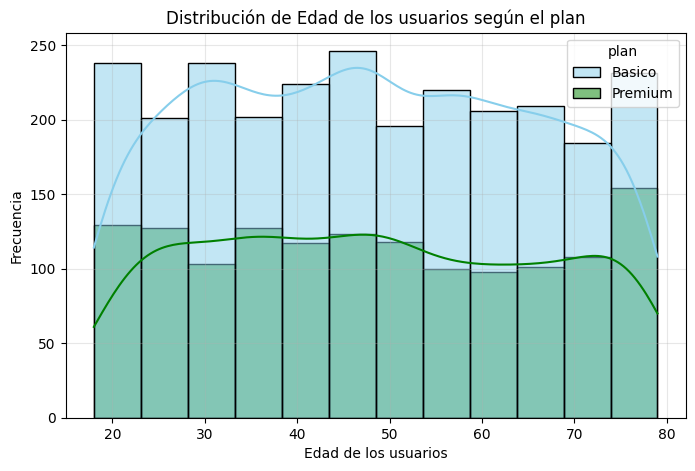

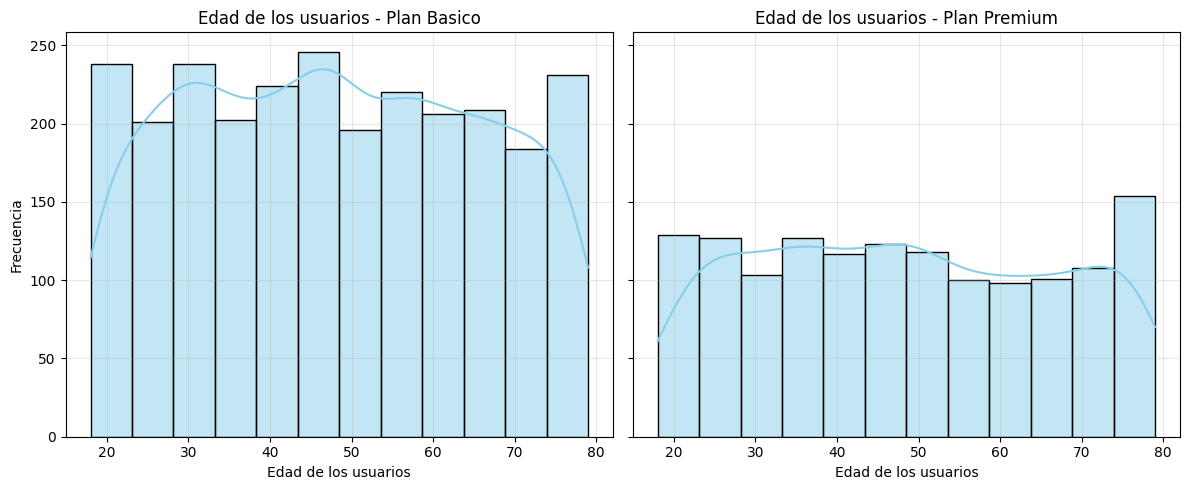

In [115]:
# Histograma para visualizar la edad (age)


columna = 'age'
plot_histograma(
    data = user_profile,
    columna = columna,
    titulo = variables[columna],
    bins = int((78-18)/5)
)

plot_histogramas_por_plan(
    data = user_profile,
    columna = columna,
    titulo = variables[columna],
    bins = int((78-18)/5)
)


💡Insights: 

- El plan Básico concentra una mayor cantidad de suscriptores que el plan Premium, lo que podría estar asociado a su menor costo de contratación y a una relación costo-beneficio percibida como más favorable por los usuarios.

- La distribución de edades de los usuarios del plan Básico es relativamente uniforme entre los distintos rangos etarios analizados, sin observarse concentraciones significativas en grupos de edad específicos. Esto sugiere que la adopción de este plan no presenta una asociación evidente con la edad de los usuarios.

- En el caso del plan Premium, aunque la distribución de edades también es relativamente homogénea, se observa una mayor concentración de usuarios en el rango etario más alto. Este comportamiento podría indicar una mayor afinidad de los usuarios de mayor edad hacia este plan en comparación con los demás grupos etarios.



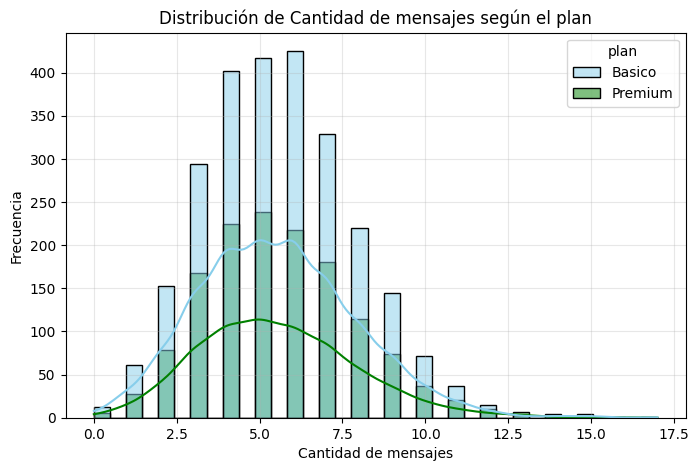

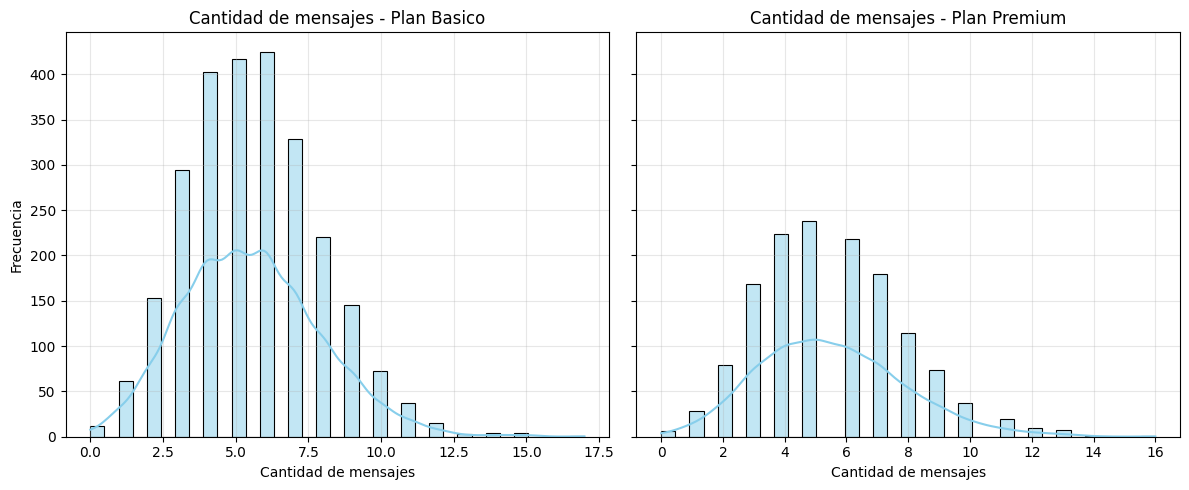

In [116]:
# Histograma para visualizar la cant_mensajes

columna = 'cant_mensajes'
plot_histograma(
    data = user_profile,
    columna = columna,
    titulo = variables[columna],
    bins = int((17.5-0)/0.5)
)

plot_histogramas_por_plan(
    data = user_profile,
    columna = columna,
    titulo = variables[columna],
    bins = int((17.5-0)/0.5)
)


💡Insights: 

- Las distribuciones de la cantidad de mensajes enviados en los planes Básico y Premium presentan características similares en términos de tendencia central y dispersión. Por lo tanto, no se observan evidencias visuales de diferencias relevantes en los patrones de uso del servicio de mensajería entre los usuarios de ambos planes.
  
- En ambos planes, la mayor concentración de usuarios se encuentra en el intervalo de entre 4 y 6 mensajes enviados, lo que sugiere un comportamiento de uso similar para la mayoría de los suscriptores.

- El plan Básico registra una mayor cantidad total de mensajes enviados. Sin embargo, este comportamiento puede atribuirse, al menos en parte, al mayor número de usuarios suscritos a dicho plan en comparación con el plan Premium.

- No se observan usuarios con una cantidad de mensajes realizados que sea significativamente superior a la registrada por la mayoría de los clientes, lo que indica una distribución relativamente concentrada alrededor de los valores más frecuentes.


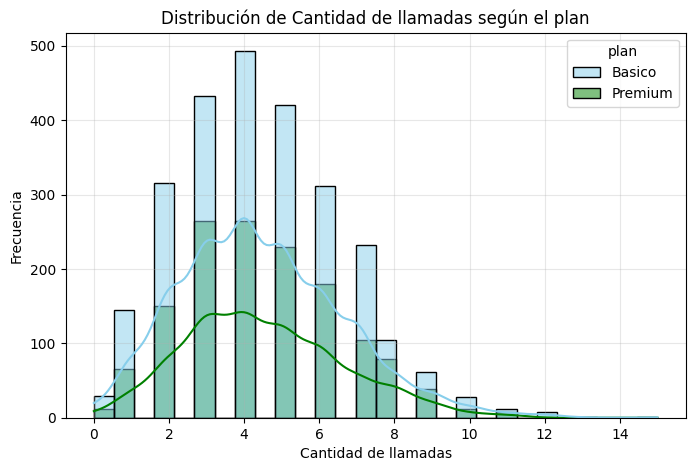

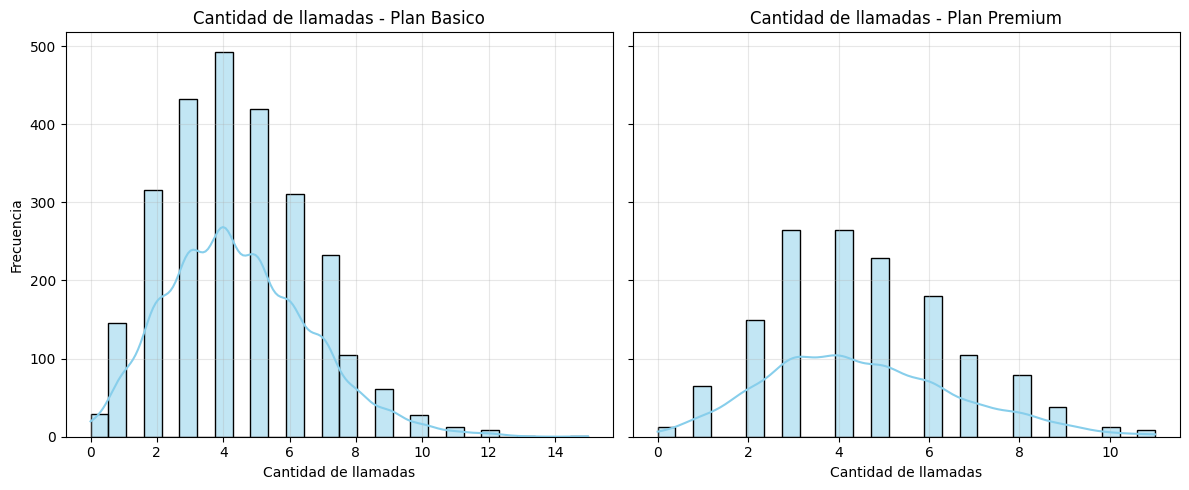

In [117]:
# Histograma para visualizar la cant_llamadas

columna = 'cant_llamadas'
plot_histograma(
    data = user_profile,
    columna = columna,
    titulo = variables[columna],
    bins = int((14-0)/0.5)
)

plot_histogramas_por_plan(
    data = user_profile,
    columna = columna,
    titulo = variables[columna],
    bins = int((14-0)/0.5)
)


💡Insights: 

- Las distribuciones de la cantidad de llamadas realizadas por los usuarios de los planes Básico y Premium presentan características similares en términos de tendencia central y dispersión. Por lo tanto, no se observan evidencias visuales de diferencias relevantes en los patrones de uso del servicio de llamadas entre los usuarios de ambos planes.
  
- En el plan Básico, la mayor concentración de usuarios se encuentra alrededor de las 4 llamadas, mientras que en el plan Premium la frecuencia más alta se observa entre 3 y 4 llamadas. Aunque existe una ligera diferencia en la ubicación de los valores más frecuentes, las distribuciones mantienen una forma general similar.

- Los usuarios suscritos al plan Básico realizan una mayor cantidad total de llamadas. Sin embargo, este comportamiento puede atribuirse, en gran medida, al mayor número de clientes asociados a este plan en comparación con el plan Premium.

- No se observan usuarios con una cantidad de llamadas significativamente superior a la registrada por la mayoría de los clientes, lo que indica una distribución relativamente concentrada alrededor de los valores más frecuentes.


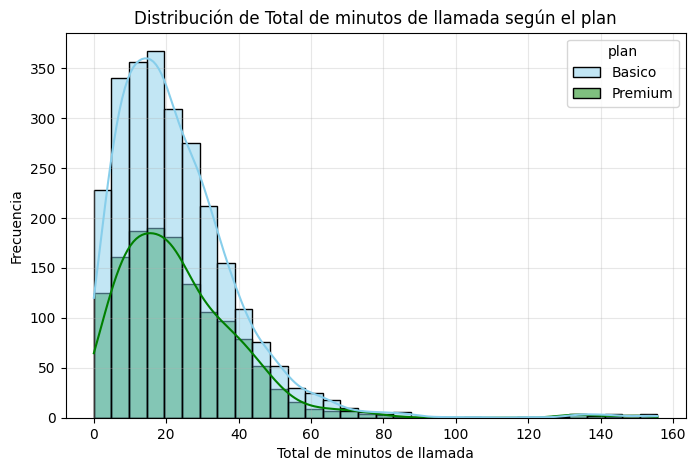

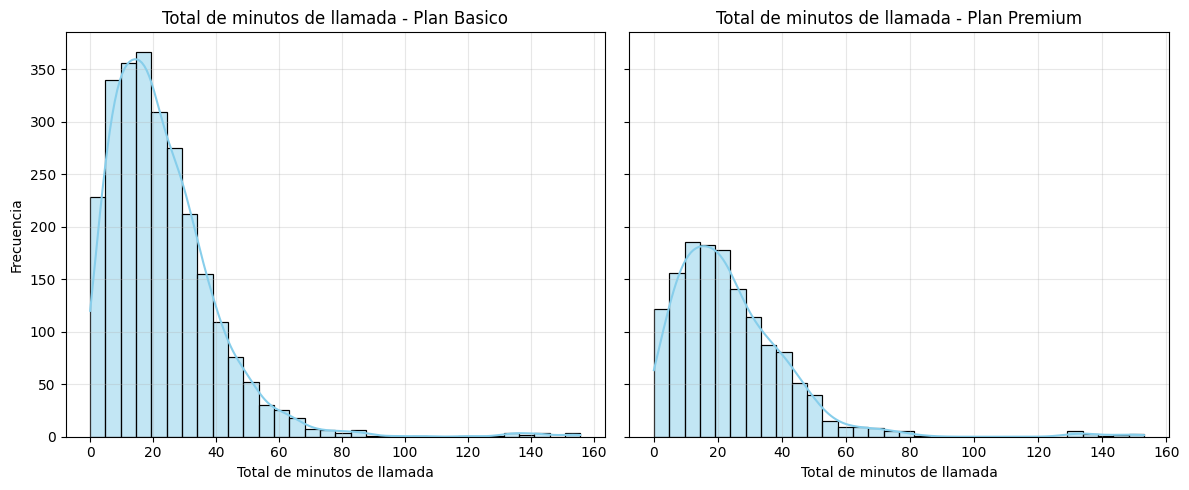

In [118]:
# Histograma para visualizar la cant_minutos_llamada

columna = 'cant_minutos_llamada'
plot_histograma(
    data = user_profile,
    columna = columna,
    titulo = variables[columna],
    bins = int((160-0)/5)
)

plot_histogramas_por_plan(
    data = user_profile,
    columna = columna,
    titulo = variables[columna],
    bins = int((160-0)/5)
)

💡Insights: 

- La distribución de la duración de las llamadas es similar para los usuarios de los planes Básico y Premium, tanto en su tendencia central como en su dispersión. A partir del análisis visual realizado, no se identifican diferencias significativas en los patrones de uso del servicio de llamadas asociadas al tipo de plan contratado.

- La distribución de la duración de las llamadas no es simétrica y presenta una cola hacia los valores más altos. Esto indica que, aunque la mayoría de las llamadas tienen duraciones relativamente bajas, existe un grupo reducido de usuarios que realiza llamadas de duración significativamente mayor.

- La duración media de las llamadas mensuales realizadas por los clientes suscritos a ambos planes es de 15 minutos.

- Aunque se observan algunos usuarios con duraciones acumuladas de llamadas superiores a los 100 minutos en ambos planes, estos casos son poco frecuentes en comparación con el conjunto de la muestra. Por tanto, pueden considerarse observaciones extremas que no alteran de manera significativa la tendencia general de la distribución.

- Los valores más elevados de duración acumulada de llamadas se observan en usuarios del plan Básico. Sin embargo, esta diferencia puede estar influenciada por la mayor cantidad de clientes suscritos a este plan, lo que incrementa la probabilidad de registrar observaciones extremas dentro de dicho grupo.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

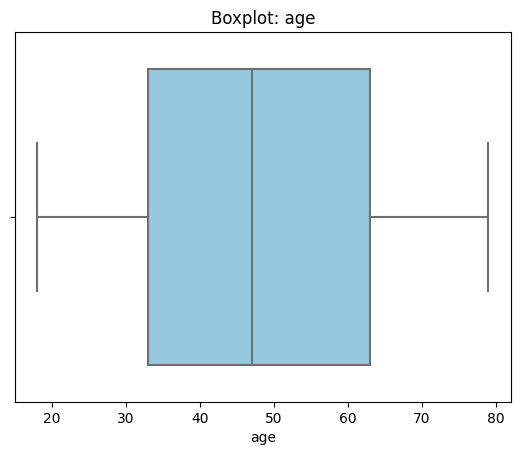

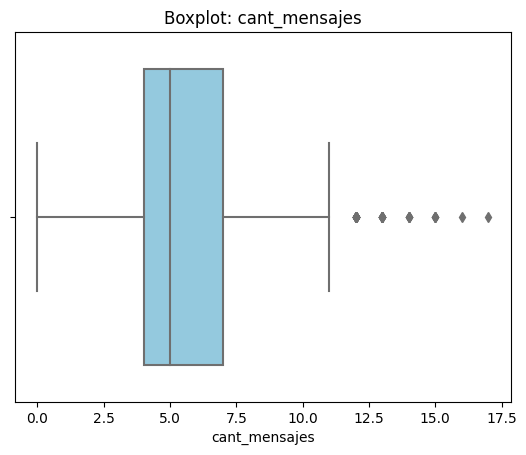

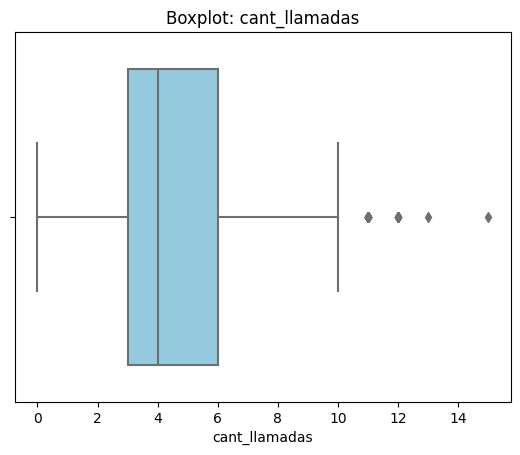

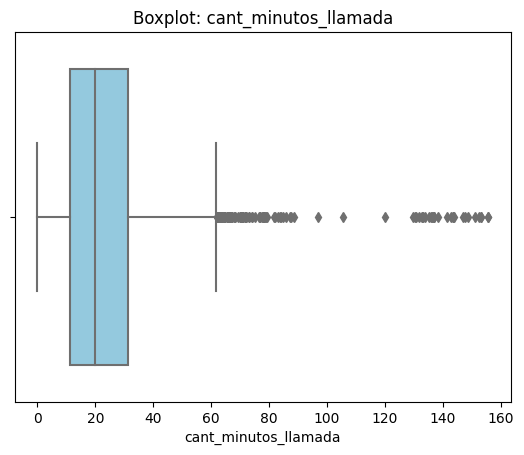

In [125]:


# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(f'{col}')
    plt.show()




💡Insights: 
- Age: No se identifican valores atípicos relevantes en la distribución de edades, lo que indica que los datos se encuentran concentrados dentro de un rango consistente con el comportamiento general de la muestra.

- cant_mensajes: Se observan valores atípicos en el extremo superior de la distribución, lo que indica la existencia de algunos usuarios que envían una cantidad de mensajes considerablemente mayor que la registrada por la mayoría de los clientes.

- cant_llamadas: Se identifican valores atípicos correspondientes a cantidades elevadas de llamadas, evidenciando la presencia de un grupo reducido de usuarios con una frecuencia de uso superior a la tendencia general.

- cant_minutos_llamada: Se observan valores atípicos asociados a duraciones acumuladas de llamadas significativamente superiores a las de la mayoría de los usuarios, lo que sugiere la existencia de casos aislados de uso intensivo del servicio.

In [126]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']



In [127]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
El valor correspondiente al tercer cuartil de los datos es de 7, mientras que el máximo valor de estos datos es 17. Debido a que no existe una gran diferencia entre ambos valores, estos valores extremos se pueden mantener dentro del estudio.
- cant_llamadas: mantener o no outliers, porqué?
El valor correspondiente al tercer cuartil de los datos es de 6, mientras que el máximo valor de estos datos es 15. Debido a que no existe una gran diferencia entre ambos valores, estos valores extremos se pueden mantener dentro del estudio.
- cant_minutos_llamada: mantener o no outliers, porqué?
A diferencia de las variables analizadas previamente, en este caso se observa una diferencia considerable entre el valor correspondiente al tercer cuartil (31.415) y el valor máximo registrado (155.69). Este comportamiento sugiere la presencia de observaciones extremas que se encuentran significativamente alejadas de la tendencia general de los datos.
En consecuencia, es recomendable analizar de manera individual estas observaciones para determinar si deben incorporarse al estudio principal. Alternativamente, dichos registros pueden constituir una fuente de información valiosa para investigaciones futuras orientadas al análisis de casos excepcionales o comportamientos extremos.

---





## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [132]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'


user_profile.loc[
    (user_profile['cant_llamadas'] < 10) &
    (user_profile['cant_mensajes'] < 10),
    'grupo_uso'
] = 'Uso medio'


user_profile.loc[
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

In [133]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [134]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[
    user_profile['age'] < 60,
    'grupo_edad'
] = 'Adulto'


user_profile.loc[
    user_profile['age'] < 30,
    'grupo_edad'
] = 'Joven'

In [135]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

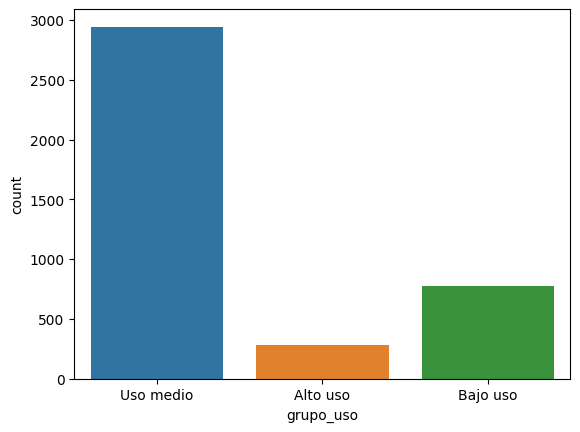

In [136]:
# Visualización de los segmentos por uso
sns.countplot(user_profile['grupo_uso'])
plt.title('Distribución de clientes de acuerdo al uso')
plt.show()

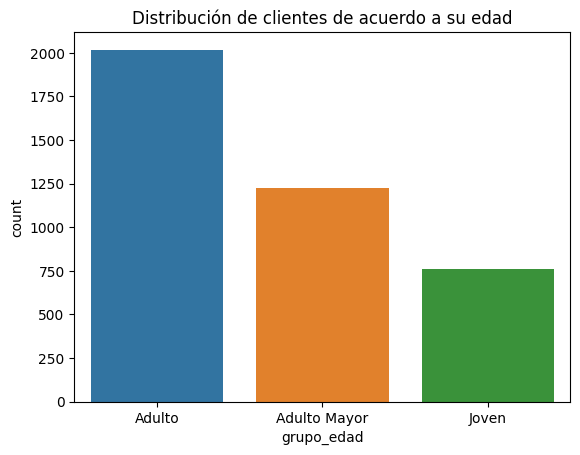

In [137]:
# Visualización de los segmentos por edad
sns.countplot(user_profile['grupo_edad'])
plt.title('Distribución de clientes de acuerdo a su edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Durante la etapa de exploración y depuración de los datos se identificaron diversas inconsistencias que requerían atención antes de proceder con el análisis. Entre los principales problemas detectados se encuentran la presencia de valores nulos, valores centinela y registros potencialmente fuera de rango.

En primer lugar, se identificaron valores faltantes en los conjuntos de datos **users** y **usage**. En el archivo **users** se detectó un total de 4 003 valores nulos, mientras que en el archivo **usage** se registraron 40 022 valores faltantes.

Respecto a la variable **churn_date**, se observó una elevada proporción de valores nulos. Debido a que esta variable no aporta información relevante para los objetivos del presente estudio, se decidió excluirla del análisis posterior.

Por otra parte, los valores nulos presentes en las variables **duration** y **length** corresponden a la estructura propia de los datos. Cuando un registro representa una llamada, la variable **length** carece de significado y permanece vacía; de forma análoga, cuando el registro corresponde a un mensaje, la variable **duration** no resulta aplicable. En consecuencia, estos valores faltantes se consideran estructurales y no requieren procesos de imputación.

Finalmente, las demás variables que presentan valores nulos poseen una proporción reducida de registros faltantes respecto al total de observaciones. Por ello, se considera que su impacto sobre los resultados del análisis es mínimo y no compromete la calidad ni la representatividad de los datos utilizados en el estudio.

Durante el proceso de depuración de los datos se identificaron dos valores centinela. El primero corresponde al valor -999 registrado en la variable edad, el cual no representa una observación válida dentro del contexto del estudio. Por esta razón, dichos registros fueron reemplazados por la mediana de la distribución de edades, preservando así las características generales de la variable y minimizando el impacto de valores artificiales sobre el análisis.

El segundo valor centinela identificado corresponde a la etiqueta '?' presente en la variable city. Dado que esta etiqueta representa información desconocida o no registrada, se decidió reemplazarla por un valor nulo, permitiendo un tratamiento más adecuado de los datos faltantes durante las etapas posteriores del análisis.

Esta modificación no tiene un impacto significativo sobre los resultados del estudio, ya que la variable city no forma parte de las variables consideradas en el análisis desarrollado.

Asimismo, se identificaron registros con fechas fuera del rango temporal considerado en el estudio. Debido a que estas observaciones no forman parte del período de interés definido para el análisis, fueron excluidas durante la etapa de depuración de los datos con el fin de preservar la consistencia y representatividad de la muestra analizada.


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Con el objetivo de facilitar el análisis de los usuarios, se definieron dos criterios de segmentación basados en la edad y en los patrones de uso de la plataforma.

La segmentación por edad se estableció en tres grupos: jóvenes, correspondientes a usuarios menores de 30 años; adultos, que comprenden usuarios con edades entre 30 y 60 años; y adultos mayores, integrados por usuarios con edades superiores a 60 años.

Por su parte, la segmentación por nivel de uso se definió a partir de la cantidad de mensajes enviados y llamadas realizadas por cada usuario. Se clasificó como Bajo Uso a aquellos usuarios que registran menos de 5 mensajes y menos de 5 llamadas; como Uso Medio a los usuarios que presentan entre 5 y 10 mensajes y entre 5 y 10 llamadas; y como Alto Uso a los usuarios que no cumplen con los criterios de las categorías anteriores.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

La mayoría de los clientes suscritos presentan un nivel de uso medio de los servicios ofrecidos por la empresa. Por el contrario, los usuarios clasificados en la categoría de alto uso representan una proporción menor de la muestra, lo que sugiere que el uso intensivo de los servicios de llamadas y mensajería no constituye el comportamiento predominante entre los suscriptores.

En cuanto a la distribución por edades, la mayor parte de los suscriptores corresponde al segmento de adultos. Por su parte, los usuarios jóvenes representan una proporción menor dentro de la base de clientes, lo que indica una menor participación de este grupo etario en los servicios ofrecidos por la empresa.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Se identificaron valores atípicos en las variables asociadas al número de llamadas realizadas, la cantidad de mensajes enviados y los minutos acumulados por los clientes durante el período analizado. En el caso de las variables correspondientes a llamadas y mensajes, los valores atípicos detectados se encuentran dentro de rangos consistentes con la distribución general de los datos, por lo que se consideran observaciones válidas y representativas de comportamientos de uso intensivo.

Por otra parte, en la variable correspondiente a los minutos acumulados de llamadas se identificaron valores atípicos significativamente alejados de la tendencia predominante de la muestra. Debido a que estas observaciones pueden ejercer una influencia desproporcionada sobre métricas estadísticas como la media, la desviación estándar y otros indicadores descriptivos, resulta conveniente evaluar su exclusión del análisis principal. Esta decisión permitiría obtener una caracterización más representativa del comportamiento general de los usuarios.

No obstante, estos registros no deben descartarse completamente, ya que pueden aportar información valiosa sobre clientes con patrones de consumo inusuales o de alta intensidad. En consecuencia, se recomienda considerarlos de forma independiente en análisis posteriores orientados a la identificación y caracterización de comportamientos atípicos.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Se recomienda diseñar estrategias comerciales, promociones o planes específicos orientados al segmento de usuarios jóvenes. Esta recomendación se fundamenta en dos aspectos principales:

    1-Los usuarios jóvenes representan el grupo menos numeroso dentro de la base de clientes actual, por lo que constituyen un segmento con potencial de crecimiento y captación de nuevos suscriptores.

    2-Este grupo etario presenta una mayor interacción con los servicios ofrecidos por la empresa, lo que podría traducirse en una mayor proporción de usuarios clasificados en categorías de uso medio y alto, favoreciendo así el incremento en el consumo de los servicios disponibles.

Asimismo, se recomienda evaluar la estructura y los beneficios asociados al plan Premium con el fin de fortalecer su propuesta de valor. Una mejora en la percepción de la relación entre costo y beneficios podría incentivar tanto la captación de nuevos usuarios como la migración de clientes actualmente suscritos al plan Básico hacia el plan Premium. Como resultado, esta estrategia podría contribuir al incremento de los ingresos y a una mayor rentabilidad de la cartera de clientes.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Presencia de datos nulos
- Presencia de valores centinelas, los cuales fueron identificados de manera efectiva
- Presencia de valor no válidos de acuerdo a los datos proporcionados. i.e: fecha


🔍 **Segmentos por Edad**

- Los adultos constituyen el segmento con mayor representación dentro de la base de clientes analizada, concentrando la mayor proporción de suscriptores de los servicios ofrecidos por la empresa.
- Los jóvenes representan el segmento menos numeroso entre los clientes suscritos. Esta situación sugiere la existencia de oportunidades para implementar estrategias de captación y fidelización dirigidas específicamente a este grupo etario.


📊 **Segmentos por Nivel de Uso**

- Los usuarios clasificados en la categoría de uso medio constituyen el segmento predominante dentro de la muestra analizada, superando en número a los grupos de bajo y alto uso. Esto indica que la mayoría de los clientes mantiene un nivel moderado de interacción con los servicios ofrecidos por la empresa.
- Los usuarios pertenecientes a la categoría de alto uso representan la menor proporción de la base de clientes. Considerando que el segmento joven presenta mayores niveles de interacción con los servicios, la implementación de estrategias orientadas a captar y fidelizar a este grupo etario podría contribuir a incrementar la cantidad de usuarios con patrones de consumo más intensivos.


➡️ Esto sugiere la existencia de oportunidades de crecimiento relacionadas con el diseño de servicios, planes y estrategias comerciales orientadas a la captación de usuarios jóvenes. Un incremento en la participación de este segmento podría traducirse en un mayor número de suscriptores, tanto en los planes Básico como Premium, contribuyendo así al crecimiento de los ingresos de la empresa.


💡 **Recomendaciones**
- Evaluar la estructura de precios y los beneficios ofrecidos por el plan Premium con el objetivo de incrementar su atractivo para nuevos clientes y para los usuarios actualmente suscritos al plan Básico. Una propuesta de valor más competitiva podría favorecer la migración hacia este plan y, en consecuencia, contribuir al incremento de los ingresos de la empresa.
  
- Diseñar planes, promociones y servicios orientados al segmento de usuarios jóvenes, dado que este grupo presenta una alta interacción con los servicios ofrecidos por la empresa. Una estrategia enfocada en este sector podría incrementar la captación de nuevos suscriptores y estimular un mayor nivel de uso de la plataforma.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`